In [ ]:
'''
Думаю, на обучении предсказательных моделей всё же стоит убрать строки с NaN в buyout_flag из обучающей выборки, поскольку это не те значения target,
которые нас интересуют по причине: строка с NaN не несёт информацию о выкупе заказа (у нас задача бинарной классификации), а предсказать выкуп
без модели мы не можем. Чисто теоретически мы можем использовать эти строки для предсказания о выкупе на инференсе, но не более того.
(Поскольку, вероятнее всего, эти строки означают незаконченный заказ)
'''

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
eda_path = Path.cwd()
base_path = eda_path.parent
data_path = base_path / 'data_preparation' / 'data'
clean_data_path = data_path / 'clean'
clean_data_file = clean_data_path / 'clean_data_with_regions.xlsx'

In [3]:
CLEAN_DATA = pd.read_excel(clean_data_file)
CLEAN_DATA

,lead_id,sale_ts,sale_date,buyout_flag,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,days_to_outcome,...,has_пояс,has_аксессуары,has_крем,n_product_categories,has_постельное,has_бады,delivery_days,delivery_group,price_group,lead_region
0,LEAD_0172,2025-03-01 05:35:06,2025-03-01,1,2025-03-07 09:11:37,2025-03-12 12:19:04,2025-03-12 12:20:05,NaT,NaT,11.28,...,False,False,False,1,False,False,5.0,средняя,до 5к,Ставропольский край
1,LEAD_0176,2025-03-01 05:51:04,2025-03-01,1,2025-03-07 09:09:52,2025-03-10 12:13:09,2025-03-10 15:23:08,NaT,NaT,9.40,...,False,False,False,1,False,False,3.0,быстрая,до 5к,Москва
2,LEAD_0177,2025-03-01 05:54:05,2025-03-01,1,2025-03-06 09:32:46,2025-03-19 03:23:15,2025-03-19 06:32:04,NaT,NaT,18.03,...,False,False,False,1,False,False,12.0,очень долгая,5к-15к,Приморский край
3,LEAD_0182,2025-03-01 06:18:06,2025-03-01,1,2025-03-05 10:11:51,2025-03-09 10:21:31,2025-03-10 15:23:20,NaT,NaT,9.38,...,False,False,False,1,False,False,4.0,средняя,до 5к,Саратовская область
4,LEAD_0180,2025-03-01 06:42:07,2025-03-01,1,2025-03-06 09:31:10,2025-03-09 06:57:12,2025-03-09 10:22:15,NaT,NaT,8.15,...,False,False,False,2,False,False,2.0,быстрая,5к-15к,Свердловская область
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,LEAD_18744,2026-03-27 15:06:15,2026-03-27,0,NaT,NaT,NaT,NaT,NaT,0.63,...,False,False,False,1,False,False,NaN,NaN,5к-15к,Волгоградская область
17962,LEAD_18782,2026-03-28 07:21:07,2026-03-28,0,NaT,NaT,NaT,NaT,NaT,0.10,...,False,False,False,1,False,False,NaN,NaN,5к-15к,Башкортостан
17963,LEAD_18784,2026-03-28 07:32:08,2026-03-28,0,NaT,NaT,NaT,NaT,NaT,1.07,...,False,True,False,3,False,False,NaN,NaN,5к-15к,Саратовская область
17964,LEAD_18794,2026-03-28 10:35:07,2026-03-28,0,NaT,NaT,NaT,NaT,NaT,0.89,...,False,False,False,2,False,False,NaN,NaN,20к+,Ханты-Мансийский автономный округ — Югра


In [4]:
TRIMMED_DATA = CLEAN_DATA.drop(['lead_tags', 'contact_Город', 'contact_id', 'lead_id', 'lead_Состав заказа', 'lead_yclid'], axis = 1)
TRIMMED_DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   sale_ts                           17966 non-null  datetime64[ns]
 1   sale_date                         17966 non-null  datetime64[ns]
 2   buyout_flag                       17966 non-null  int64         
 3   handed_to_delivery_ts             17541 non-null  datetime64[ns]
 4   issued_or_pvz_ts                  17206 non-null  datetime64[ns]
 5   received_ts                       14882 non-null  datetime64[ns]
 6   rejected_ts                       2630 non-null   datetime64[ns]
 7   returned_ts                       2533 non-null   datetime64[ns]
 8   days_to_outcome                   17873 non-null  float64       
 9   closed_ts                         17873 non-null  datetime64[ns]
 10  lead_price                        17966 non-nu

In [6]:
CLEAN_DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   lead_id                           17966 non-null  object        
 1   sale_ts                           17966 non-null  datetime64[ns]
 2   sale_date                         17966 non-null  datetime64[ns]
 3   buyout_flag                       17966 non-null  int64         
 4   handed_to_delivery_ts             17541 non-null  datetime64[ns]
 5   issued_or_pvz_ts                  17206 non-null  datetime64[ns]
 6   received_ts                       14882 non-null  datetime64[ns]
 7   rejected_ts                       2630 non-null   datetime64[ns]
 8   returned_ts                       2533 non-null   datetime64[ns]
 9   days_to_outcome                   17873 non-null  float64       
 10  closed_ts                         17873 non-nu

**Интернет-страницы о метриках взаимосвязей признаков:**
* ?Дмитрий Макаров: https://www.dmitrymakarov.ru/learning/relationship/
* ?Habr: https://habr.com/ru/companies/gazprombank/articles/881386/

In [7]:
CLEAN_DATA_real = CLEAN_DATA.select_dtypes(['int64', 'float64'])
CLEAN_DATA_categorical = CLEAN_DATA.select_dtypes(['object', 'bool'])
CLEAN_DATA_time = CLEAN_DATA.select_dtypes(['datetime64[ns]'])
#CLEAN_DATA_real

In [59]:
all_corr = CLEAN_DATA_real.corr()

In [21]:
!pip install phik

In [5]:
from scipy.stats import chi2_contingency
from tqdm import tqdm
from CythonFiles.corrFuncs import nancorr_CramersV_fast as CramersV
def CategoricalUniform(DATA):
    CUdData = {}
    for label in DATA.columns.tolist():
        column = DATA[label]
        unique = pd.unique(column).tolist()
        transformDict = {i: j for i, j in zip(unique, range(len(unique)))}
        CUdData[label] = column.apply(lambda x: transformDict[x])
    return pd.DataFrame(CUdData)
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    v = np.sqrt(chi2 / (n * min_dim))
    return v
def cramers_v_matrix_optimized(DATA):
    categorical_columns = DATA.columns.tolist()
    n_cols = len(categorical_columns)
    v_matrix = np.eye(n_cols)
    unique_values = {col: DATA[col].fillna('MISSING').astype(str) for col in categorical_columns}
    
    for i in range(n_cols):
        for j in range(i + 1, n_cols):
            col1, col2 = categorical_columns[i], categorical_columns[j]
            
            contingency = pd.crosstab(unique_values[col1], unique_values[col2])
            v_value = cramers_v(contingency.values)
            
            v_matrix[i, j] = v_value
            v_matrix[j, i] = v_value
    
    return pd.DataFrame(v_matrix, index=categorical_columns, columns=categorical_columns)
def fullCramersV(DATA):
    categorical_columns = DATA.columns.tolist()
    v_matrix = CramersV(CategoricalUniform(DATA).to_numpy())
    return pd.DataFrame(v_matrix, index=categorical_columns, columns=categorical_columns)

In [25]:
from datetime import datetime
TRIMMED_DATA_categorical = TRIMMED_DATA.select_dtypes(['object', 'bool'])
CramerCalc = TRIMMED_DATA_categorical[['lead_Вид оплаты', 'lead_Служба доставки']]
strt = datetime.now()
Cramer = fullCramersV(TRIMMED_DATA_categorical) #CLEAN_DATA считает долго!
end = datetime.now()
dur = end-strt
print(dur)

0:00:00.072981


In [12]:
strt = datetime.now()
PyCramer = cramers_v_matrix_optimized(TRIMMED_DATA_categorical)
end = datetime.now()
dur = end-strt
print(dur)

0:00:00.313165


In [6]:
#Добавить F-value, p-value, Phik-value, коэффициент Стьюдента, коэффициент Фишера
CheddockClasses = ['Нет корреляции', 'Слабая корреляция', 'Умеренная корреляция', 'Заметная корреляция', 'Тесная корреляция', 'Очень тесная корреляция', 'Функциональная корреляция']
CramersVClasses = ['Слабая корреляция', 'Умеренная корреляция', 'Сильная корреляция']
PhiKClasses = ['Слабая корреляция', 'Умеренная корреляция', 'Заметная корреляция', 'Высокая корреляция', 'Очень высокая корреляция']
def SeriesClassification(x, func, *args):
    return x.apply(func, args = args)
def CheddockClassification(x, classtype = 'label'):
    global CheddockClasses
    classes = CheddockClasses
    ax = abs(x)
    Class = 6
    if ax<0.1:
        Class = 0
    elif (0.1<=ax<0.3):
        Class = 1
    elif (0.3<=ax<0.5):
        Class = 2
    elif (0.5<=ax<0.7):
        Class = 3
    elif (0.7<=ax<0.9):
        Class = 4
    elif (0.9<=ax<1):
        Class = 5
    if classtype == 'label':
        return classes[Class]
    return Class
def CramersVClassification(x, classtype = 'label'):
    global CramersVClasses
    classes = CramersVClasses
    Class = 2
    if x<=0.2:
        Class = 0
    elif (0.2<x<=0.6):
        Class = 1
    if classtype == 'label':
        return classes[Class]
    return Class
def pvalueClassification(x, classtype = 'label', importance_level = 0.05):
    classes = ['Есть статистически значимые различия', 'Нет статистически значимых различий']
    Class = 1
    if x<importance_level:
        Class = 0
    if classtype == 'label':
        return classes[Class]
    return Class
def PhiKClassification(x, classtype = 'label'):
    global PhiKClasses
    classes = PhiKClasses
    Class = 4
    if x<=0.2:
        Class = 0
    elif (0.2<x<=0.4):
        Class = 1
    elif (0.4<x<=0.6):
        Class = 2
    elif (0.6<x<=0.8):
        Class = 3
    if classtype == 'label':
        return classes[Class]
    return Class
def FindCorrelations(DATA, corr_types = ['pierson', 'spearman', 'kendall', 'Cramer\'s V', 'PhiK']):
    Corrs = {}
    DATA_real = DATA.select_dtypes(['int64', 'float64', 'datetime64[ns]'])
    DATA_real.drop('buyout_flag', axis = 1, inplace = True)
    DATA_real = pd.concat([DATA['buyout_flag'], DATA_real], axis = 1)
    DATA_categorical = DATA.select_dtypes(['object', 'bool'])
    DATA_categorical = pd.concat([DATA['buyout_flag'], DATA_categorical], axis = 1)
    DATA_time = DATA.select_dtypes(['datetime64[ns]'])
    if 'pierson' in corr_types:
        Corrs['pierson'] = DATA_real.corr()
        Corrs['pierson_classes'] = Corrs['pierson'].apply(SeriesClassification, args = (CheddockClassification, 0, ))
        Corrs['pierson_labeledClasses'] = Corrs['pierson'].apply(SeriesClassification, args = (CheddockClassification, ))
    if 'spearman' in corr_types:
        Corrs['spearman'] = DATA_real.corr(method = 'spearman')
        Corrs['spearman_classes'] = Corrs['spearman'].apply(SeriesClassification, args = (CheddockClassification, 0, ))
        Corrs['spearman_labeledClasses'] = Corrs['spearman'].apply(SeriesClassification, args = (CheddockClassification, ))
    if 'kendall' in corr_types:
        Corrs['kendall'] = DATA_real.corr(method = 'kendall')
        Corrs['kendall_classes'] = Corrs['kendall'].apply(SeriesClassification, args = (CheddockClassification, 0, ))
        Corrs['kendall_labeledClasses'] = Corrs['kendall'].apply(SeriesClassification, args = (CheddockClassification, ))
    if 'Cramer\'s V' in corr_types:
        Corrs['Cramer\'s V'] = fullCramersV(DATA_categorical)
        Corrs['Cramer\'s V_classes'] = Corrs['Cramer\'s V'].apply(SeriesClassification, args = (CramersVClassification, 0, ))
        Corrs['Cramer\'s V_labeledClasses'] = Corrs['Cramer\'s V'].apply(SeriesClassification, args = (CramersVClassification, ))
    if 'PhiK' in corr_types:
        import phik
        from phik import resources, report
        Corrs['PhiK'] = DATA.select_dtypes(['int64', 'float64', 'object', 'bool']).phik_matrix(bins=10, quantile=False, noise_correction=False, dropna=True, njobs=1, verbose=True)
        Corrs['PhiK_classes'] = Corrs['PhiK'].apply(SeriesClassification, args = (PhiKClassification, 0, ))
        Corrs['PhiK_labeledClasses'] = Corrs['PhiK'].apply(SeriesClassification, args = (PhiKClassification, ))
    return Corrs

In [7]:
def buyoutCorrelations(Corrs):
    return pd.DataFrame({i: j['buyout_flag'] for i, j in Corrs.items()})
def pbc(continuous, binary):
    df = pd.concat([continuous, binary], axis = 1)
    df = df.dropna()
    cont = df.iloc[:, 0]
    binah = df.iloc[:, 1]
    continuous_values = np.array(cont, dtype = np.float64)
    binary_values = np.unique(binah, return_inverse = True)[1]
    group0 = continuous_values[np.argwhere(binary_values == 0).flatten()]
    group1 = continuous_values[np.argwhere(binary_values == 1).flatten()]
 
    mean0, mean1 = np.mean(group0) if len(group0)>0 else 0, np.mean(group1) if len(group1)>0 else 0
    n0, n1, n = len(group0), len(group1), len(continuous_values)

    std = continuous_values.std()

    return (mean1-mean0)/std*np.sqrt((n1*n0)/(n*(n-1)))
def buyout_pbc(DATA):
    DATA_real = DATA.select_dtypes(['int64', 'float64', 'datetime64[ns]'])
    buyout = DATA_real['buyout_flag']
    DATA_real.drop('buyout_flag', axis = 1, inplace = True)
    columns = DATA_real.columns.tolist()
    bpbc_np = np.array([1.]+[pbc(DATA_real[i], buyout) for i in columns])
    bpbc = pd.DataFrame(bpbc_np, index = ['buyout_flag']+columns, columns=['buyout_flag'])
    Corrs = {'pbc': bpbc}
    Corrs['pbc_classes'] = Corrs['pbc'].apply(SeriesClassification, args = (CheddockClassification, 0, ))
    Corrs['pbc_labeledClasses'] = Corrs['pbc'].apply(SeriesClassification, args = (CheddockClassification, ))
    return Corrs

In [8]:
trimmed_corr_types = ['pierson', 'spearman', 'kendall', 'Cramer\'s V', 'PhiK']
Corrs = FindCorrelations(TRIMMED_DATA, trimmed_corr_types)

interval columns not set, guessing: ['buyout_flag', 'days_to_outcome', 'lead_price', 'contact_LTV', 'contact_Число сделок', 'lead_Скидка', 'n_product_categories', 'delivery_days']


C:\Users\andra\AppData\Local\Programs\Python\Python311\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable lead_Оплата МОП for analysis 1. Dropping this column
  warnings.warn(


In [24]:
nontrimmed_corr_types = ['pierson', 'spearman', 'kendall', 'Cramer\'s V']
strt = datetime.now()
NonTrimmedCorrs = FindCorrelations(CLEAN_DATA, nontrimmed_corr_types)
end = datetime.now()
dur = end-strt
print(dur)

In [26]:
NonTrimmedCorrs['Cramer\'s V']

,buyout_flag,lead_id,lead_responsible_user_id,lead_tags,lead_yclid,lead_Служба доставки,lead_Вид оплаты,lead_Проблема,lead_Состав заказа,lead_Оплата МОП,contact_id,contact_Город,lead_Источник,lead_Условный отказ,lead_Тариф Доставки,lead_Квалификация лида
buyout_flag,1.000000,1.0,0.092096,0.352824,0.779280,0.097961,0.095173,0.074394,0.871965,0.374078,0.964300,0.605430,0.084933,0.875991,0.072135,0.099670
lead_id,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
lead_responsible_user_id,0.092096,1.0,1.000000,0.334560,0.813247,0.184968,0.152733,0.117730,0.925905,0.518107,0.968942,0.598988,0.210839,0.098061,0.130070,0.346708
lead_tags,0.352824,1.0,0.334560,1.000000,0.604436,0.277172,0.315909,0.327065,0.942048,0.569854,0.877813,0.505079,0.673186,0.483774,0.283676,0.401877
lead_yclid,0.779280,1.0,0.813247,0.604436,1.000000,0.651067,0.478940,0.614190,0.860740,0.706719,0.956805,0.755769,0.422824,0.638405,0.756124,0.774864
lead_Служба доставки,0.097961,1.0,0.184968,0.277172,0.651067,1.000000,0.420778,0.292186,0.926502,0.086042,0.950317,0.723422,0.041123,0.158192,0.544150,0.052020
lead_Вид оплаты,0.095173,1.0,0.152733,0.315909,0.478940,0.420778,1.000000,0.272608,0.952948,0.029592,0.918358,0.678555,0.082057,0.152586,0.043785,0.061803
lead_Проблема,0.074394,1.0,0.117730,0.327065,0.614190,0.292186,0.272608,1.000000,0.933673,0.206589,0.898615,0.485410,0.108538,0.074020,0.101029,0.129235
lead_Состав заказа,0.871965,1.0,0.925905,0.942048,0.860740,0.926502,0.952948,0.933673,1.000000,0.928759,0.919147,0.878200,0.950892,0.822120,0.898556,0.909424
lead_Оплата МОП,0.374078,1.0,0.518107,0.569854,0.706719,0.086042,0.029592,0.206589,0.928759,1.000000,0.950045,0.573160,0.269521,0.340337,0.257702,0.634044


In [32]:
buyout_corr = buyoutCorrelations(Corrs)

In [33]:
buyout_corr

,pierson,pierson_classes,pierson_labeledClasses,spearman,spearman_classes,spearman_labeledClasses,kendall,kendall_classes,kendall_labeledClasses,Cramer's V,Cramer's V_classes,Cramer's V_labeledClasses,PhiK,PhiK_classes,PhiK_labeledClasses
buyout_flag,1.000000,6.0,Функциональная корреляция,1.000000,6.0,Функциональная корреляция,1.000000,6.0,Функциональная корреляция,1.000000,2.0,Сильная корреляция,1.000000,4.0,Очень высокая корреляция
closed_ts,0.155265,1.0,Слабая корреляция,-0.226973,1.0,Слабая корреляция,-0.185337,1.0,Слабая корреляция,NaN,NaN,NaN,NaN,NaN,NaN
contact_LTV,0.008746,0.0,Нет корреляции,-0.000736,0.0,Нет корреляции,-0.000601,0.0,Нет корреляции,NaN,NaN,NaN,0.032803,0.0,Слабая корреляция
contact_Число сделок,0.008421,0.0,Нет корреляции,-0.005833,0.0,Нет корреляции,-0.005577,0.0,Нет корреляции,NaN,NaN,NaN,0.025466,0.0,Слабая корреляция
days_to_outcome,-0.701272,4.0,Тесная корреляция,-0.492031,2.0,Умеренная корреляция,-0.401915,2.0,Умеренная корреляция,NaN,NaN,NaN,0.942407,4.0,Очень высокая корреляция
handed_to_delivery_ts,0.310605,2.0,Умеренная корреляция,0.044415,0.0,Нет корреляции,0.036276,0.0,Нет корреляции,NaN,NaN,NaN,NaN,NaN,NaN
has_promo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.071192,0.0,Слабая корреляция,NaN,NaN,NaN
has_yclid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.099602,0.0,Слабая корреляция,NaN,NaN,NaN
has_аксессуары,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018368,0.0,Слабая корреляция,NaN,NaN,NaN
has_бандаж_шейный,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044386,0.0,Слабая корреляция,NaN,NaN,NaN


In [93]:
buyoutCorrelations(buyout_pbc(TRIMMED_DATA))

,pbc,pbc_classes,pbc_labeledClasses
buyout_flag,1.000000,6,Функциональная корреляция
sale_ts,-0.049426,0,Нет корреляции
sale_date,-0.049459,0,Нет корреляции
handed_to_delivery_ts,-0.042767,0,Нет корреляции
issued_or_pvz_ts,-0.044593,0,Нет корреляции
received_ts,-0.000000,0,Нет корреляции
rejected_ts,0.014522,0,Нет корреляции
returned_ts,-0.111768,1,Слабая корреляция
days_to_outcome,-0.701291,4,Тесная корреляция
closed_ts,-0.251979,1,Слабая корреляция


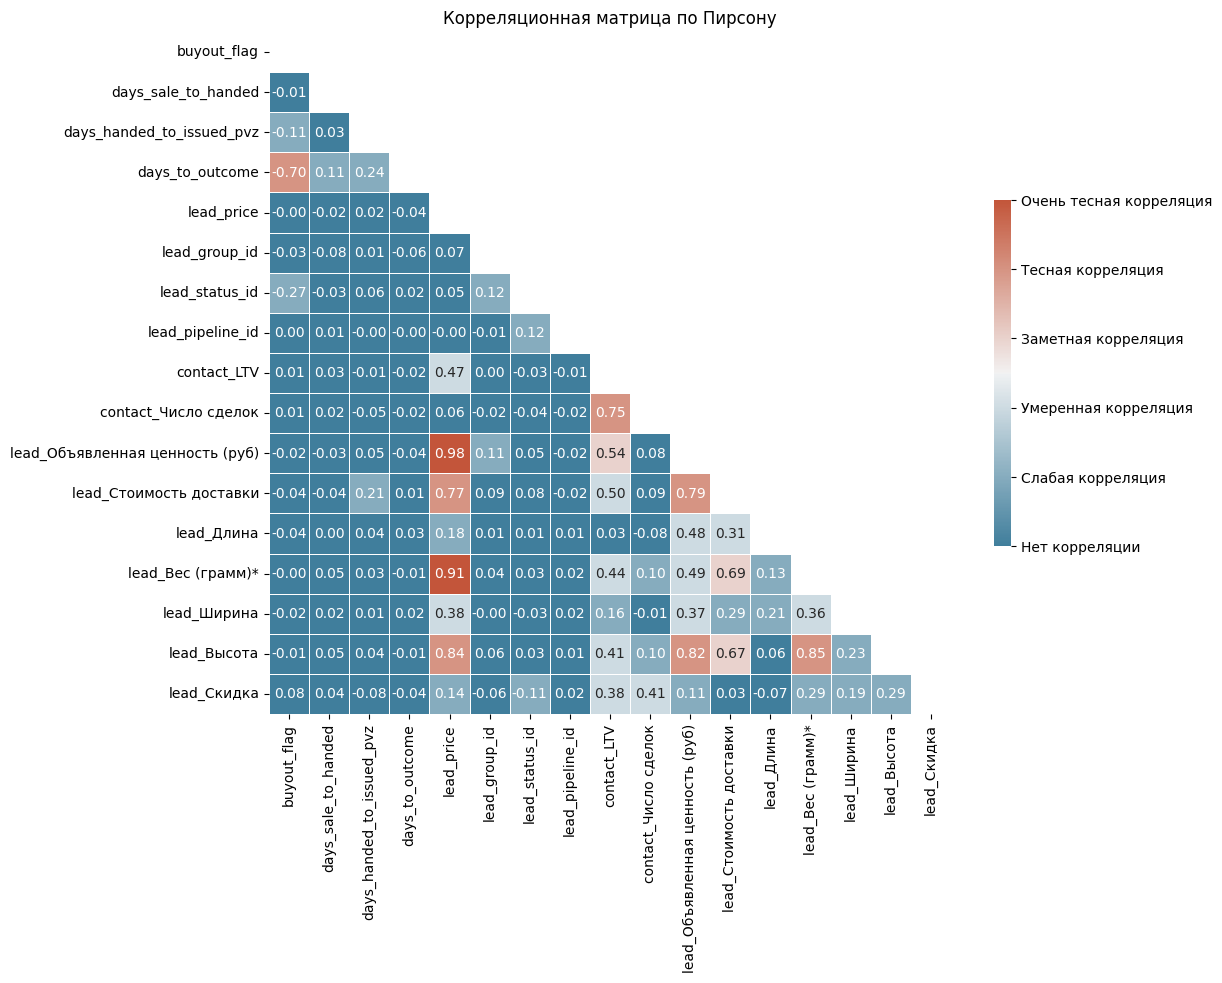

In [141]:
mask = np.triu(np.ones_like(Corrs['pierson_classes'], dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

cax = sns.heatmap(Corrs['pierson_classes'], mask=mask, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs['pierson'], fmt = '.2f')
cax.set_title('Корреляционная матрица по Пирсону')
cbar = cax.collections[0].colorbar
cbar.set_ticks(ticks=[i for i in range(len(CheddockClasses[:-1]))], labels=CheddockClasses[:-1])

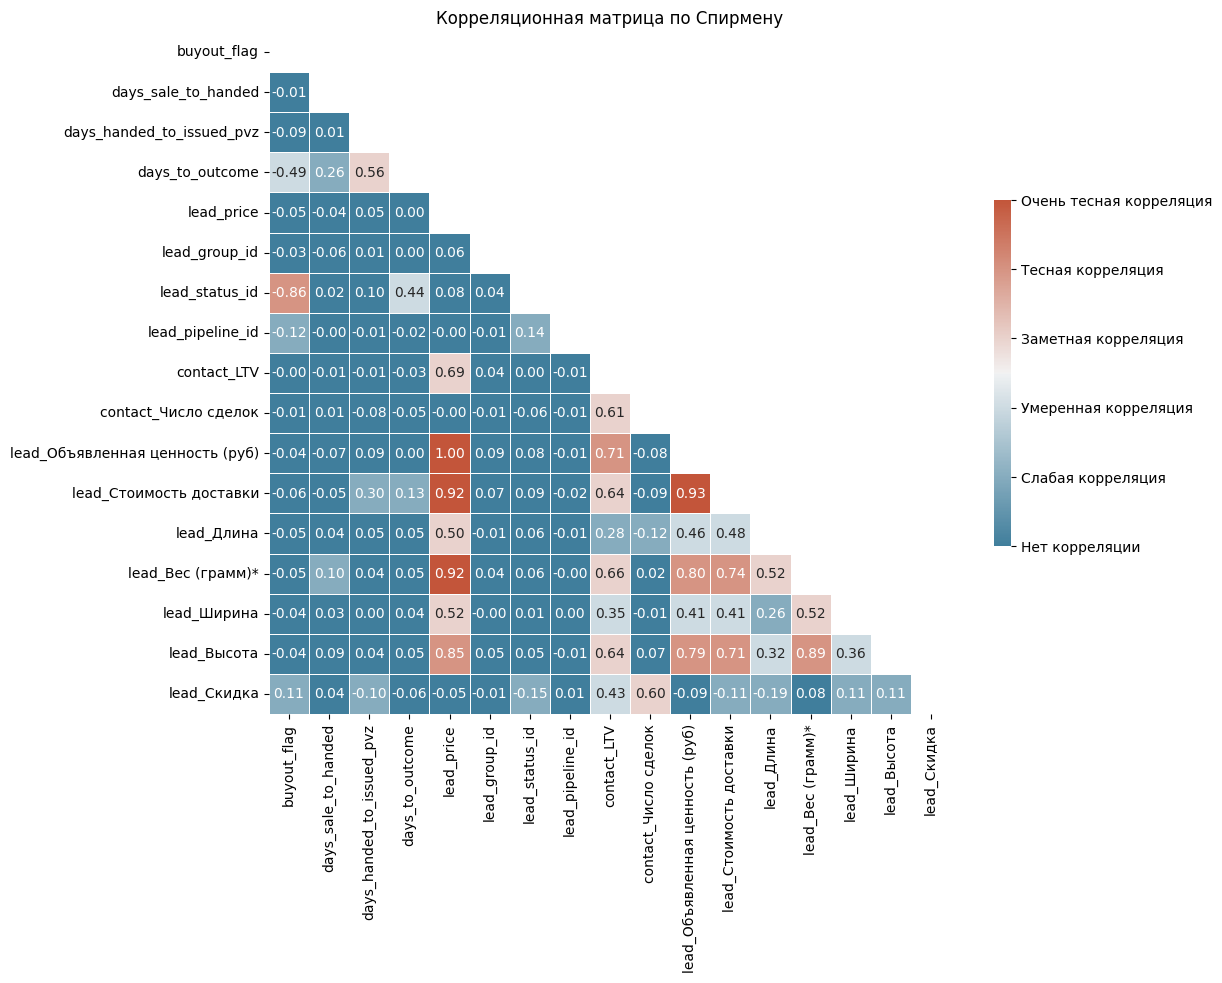

In [140]:
mask = np.triu(np.ones_like(Corrs['spearman_classes'], dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

cax = sns.heatmap(Corrs['spearman_classes'], mask=mask, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs['spearman'], fmt = '.2f')
cax.set_title('Корреляционная матрица по Спирмену')
cbar = cax.collections[0].colorbar
cbar.set_ticks(ticks=[i for i in range(len(CheddockClasses[:-1]))], labels=CheddockClasses[:-1])

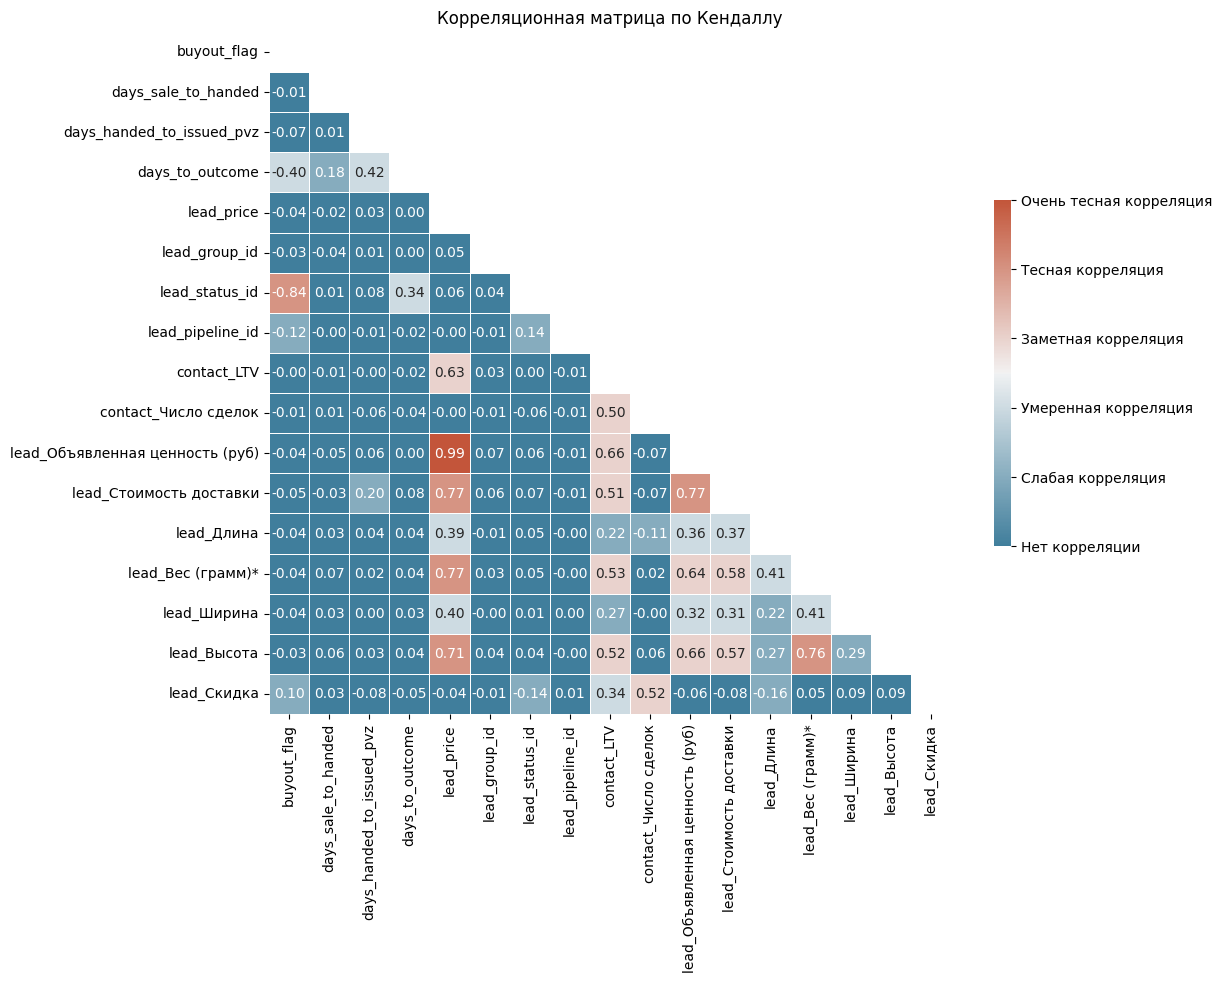

In [139]:
mask = np.triu(np.ones_like(Corrs['kendall_classes'], dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

cax = sns.heatmap(Corrs['kendall_classes'], mask=mask, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs['kendall'], fmt = '.2f')
cax.set_title('Корреляционная матрица по Кендаллу')
cbar = cax.collections[0].colorbar
cbar.set_ticks(ticks=[i for i in range(len(CheddockClasses[:-1]))], labels=CheddockClasses[:-1])

In [9]:
image_path = eda_path / 'Images'

In [14]:
def VisualizeCorrMatrix(Corrs, corr_type, fmt = '2', save = False, image_path = '', title = '1'):
    mask = np.triu(np.ones_like(Corrs[corr_type+'_classes'], dtype=bool))

    f, ax = plt.subplots(figsize=(11, 9))

    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    title = 'Корреляционная матрица по '
    classes = []
    global CheddockClasses
    global CramersVClasses
    global PhiKClasses
    vmax = 5
    if corr_type == 'pierson':
        classes = CheddockClasses[:-1]
        title+='Пирсону'
    elif corr_type == 'spearman':
        classes = CheddockClasses[:-1]
        title+='Спирмену'
    elif corr_type == 'kendall':
        classes = CheddockClasses[:-1]
        title+='Кендаллу'
    elif corr_type == 'Cramer\'s V':
        classes = CramersVClasses
        title+='Крамеру-В'
        vmax = 2
    elif corr_type == 'PhiK':
        classes = PhiKClasses
        title+='Ф-К'
        vmax = 4
    if fmt=='0':
        cax = sns.heatmap(Corrs[corr_type+'_classes'], mask=mask, cmap=cmap, vmax = vmax, square=True, linewidths=.5, cbar_kws={"shrink": .5})
        cax.set_title(title)
        cbar = cax.collections[0].colorbar
        cbar.set_ticks(ticks=[i for i in range(len(classes))], labels=classes)
        plt.show()
    else:
        cax = sns.heatmap(Corrs[corr_type+'_classes'], mask=mask, cmap=cmap, vmax = vmax, square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = Corrs[corr_type], fmt = f'.{fmt}f')
        cax.set_title(title)
        cbar = cax.collections[0].colorbar
        cbar.set_ticks(ticks=[i for i in range(len(classes))], labels=classes)
        plt.show()
    if save:
        f.tight_layout()
        f.savefig(image_path / (title+corr_type+'.png'))

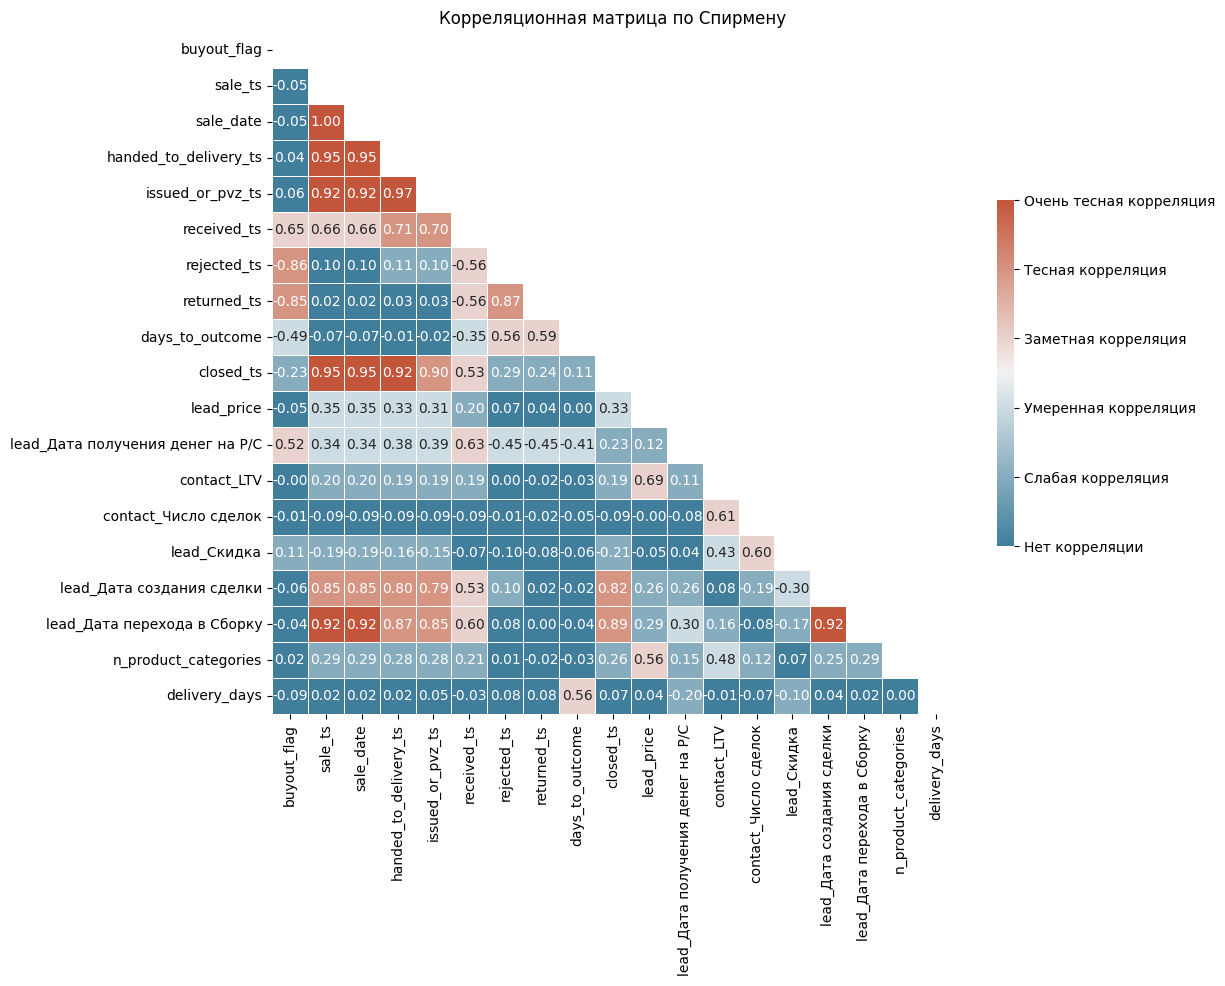

In [15]:
VisualizeCorrMatrix(Corrs, 'spearman', save = True, image_path = image_path, title = 'Corr_matrix_')

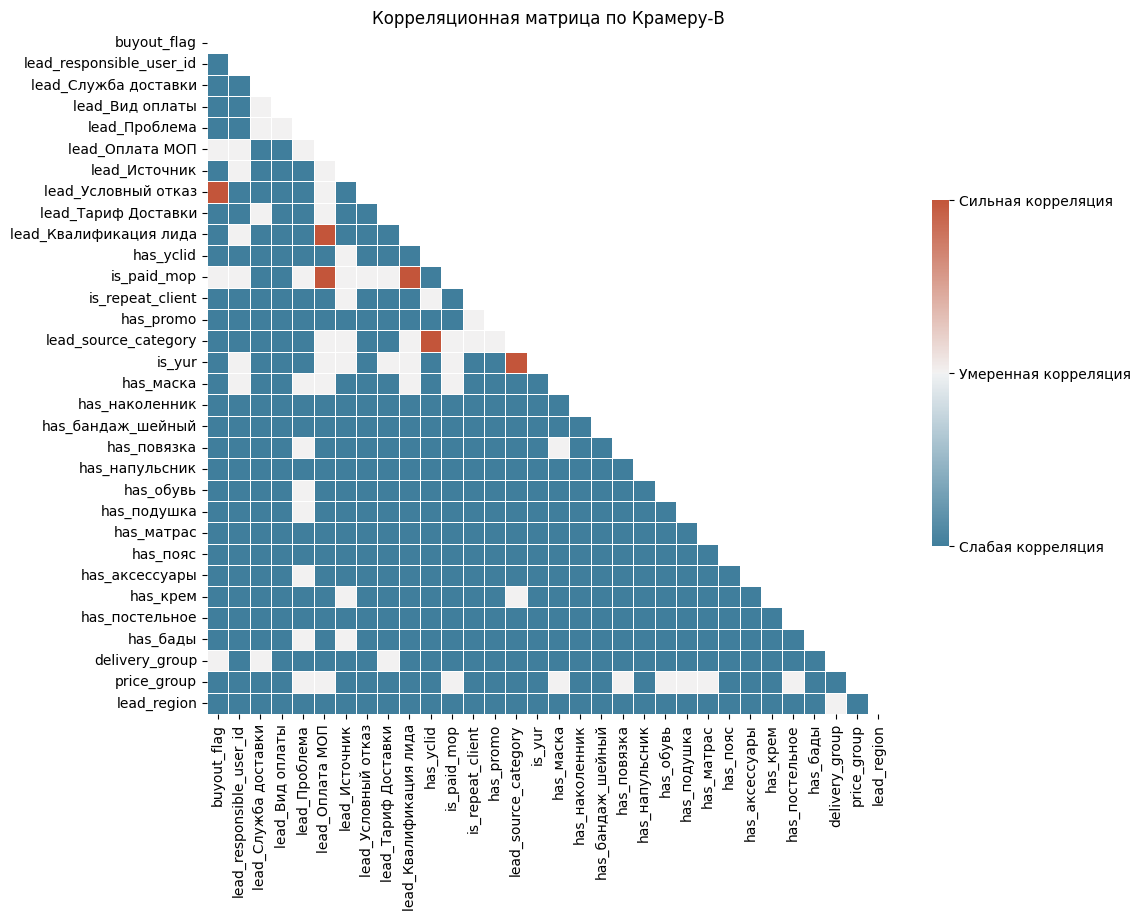

In [16]:
VisualizeCorrMatrix(Corrs, 'Cramer\'s V', fmt = '0', save = True, image_path = image_path, title = 'Corr_matrix_')

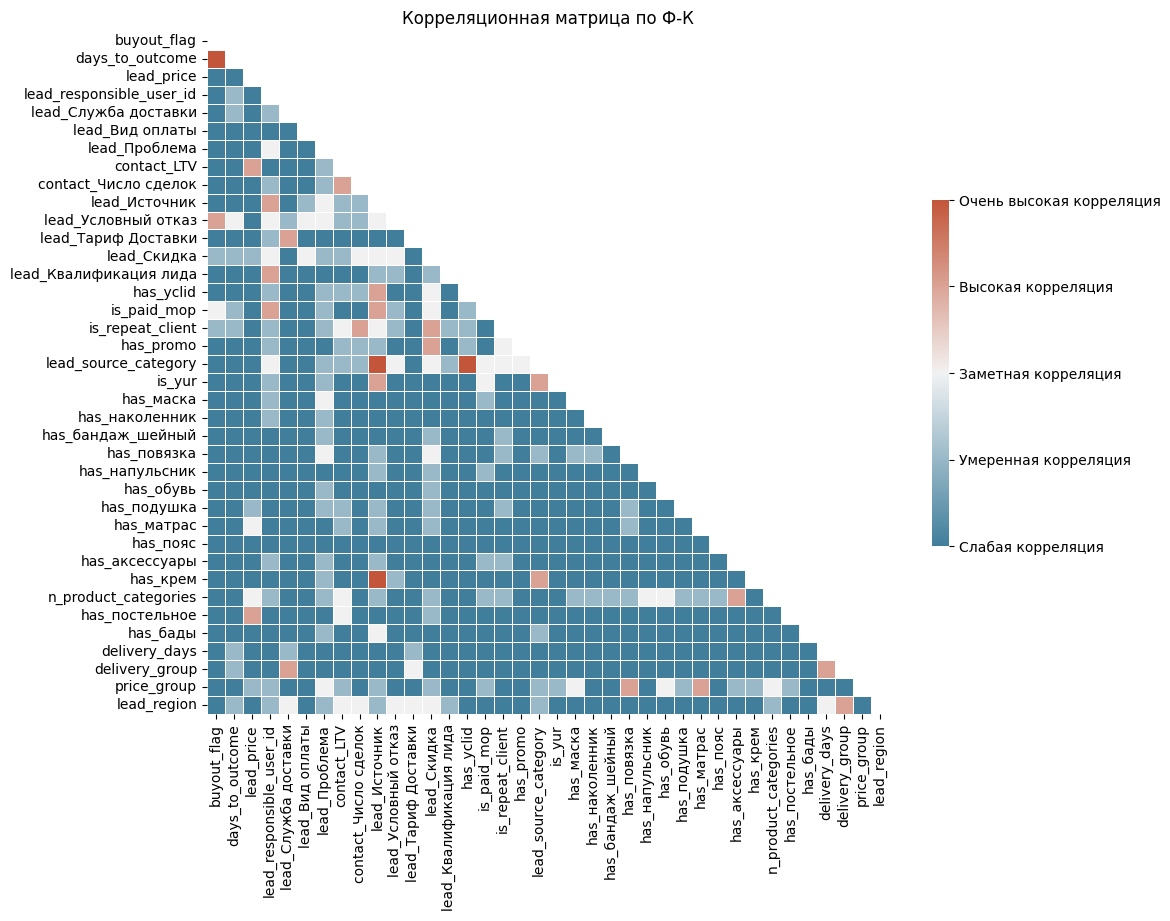

In [17]:
VisualizeCorrMatrix(Corrs, 'PhiK', fmt = '0', save = True, image_path = image_path, title = 'Corr_matrix_')

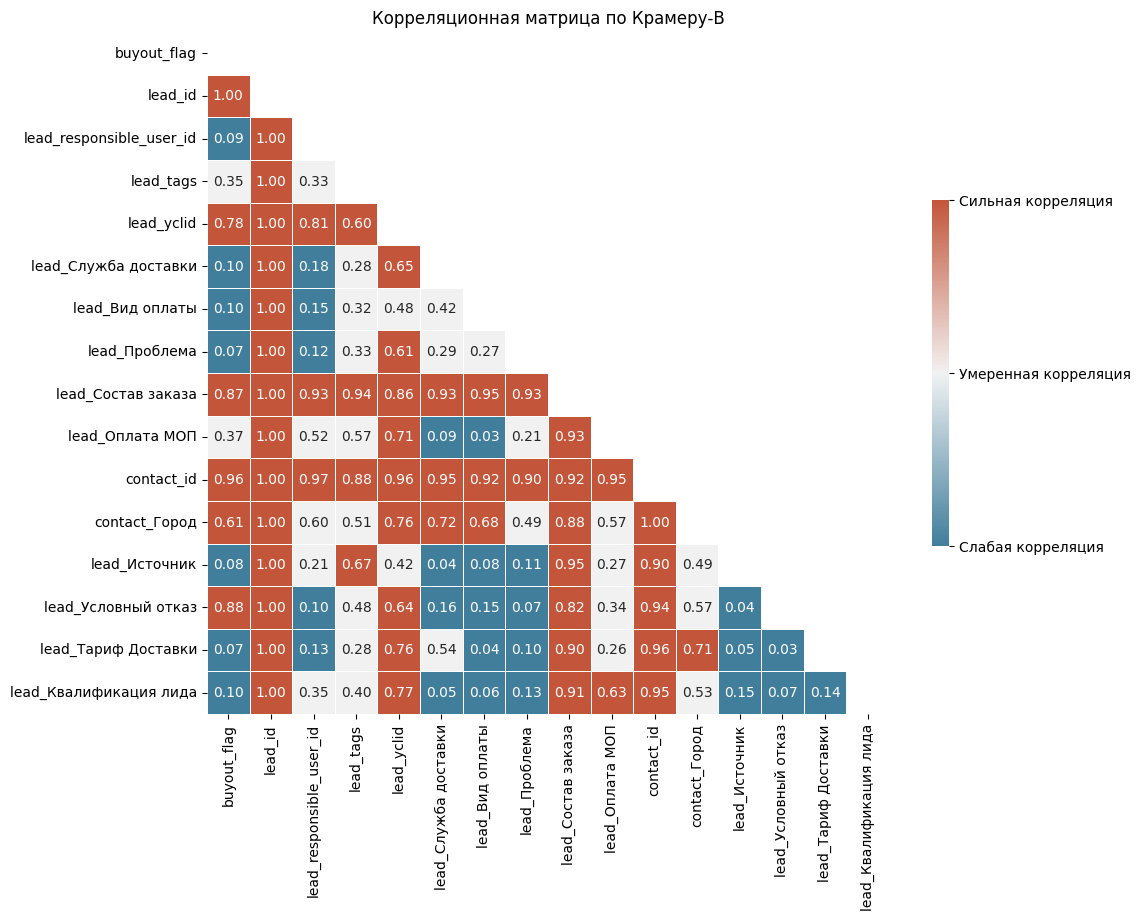

'\nПолагаю, околоединичная высокая корреляция у удалённых строк вызвана слишком большим количеством уникальных классов.\nНапример, строка lead_id имеет количество классов равное количеству строк, что и вызывает корреляцию, строго равную единице.\nПрактически все эти строки всё ещё стоит удалить, поскольку их классы в открытой задаче могут быть не ограничены сверху по количеству,\nчто не позволит корректно обучить ML модель (правда, используя примитивный one-hot, не уверен в идее использовать для этой задачи сложный embedding).\nКроме того предлагаю по возможности разделить столбцы, хранящие внутри себя списки вещей/данных (перечисление через запятую/точку с запятой ...),\nнапример, на столбцы всех уникальных значений с флагом в строках о наличии/отсутствии того или иного элемента (0/1, True/False) \nНапример, таковыми являются lead_Состав заказа, lead_tags...\n'

In [27]:
'''
Полагаю, околоединичная высокая корреляция у удалённых строк вызвана слишком большим количеством уникальных классов.
Например, строка lead_id имеет количество классов равное количеству строк, что и вызывает корреляцию, строго равную единице.
Практически все эти строки всё ещё стоит удалить, поскольку их классы в открытой задаче могут быть не ограничены сверху по количеству,
что не позволит корректно обучить ML модель (правда, используя примитивный one-hot, не уверен в идее использовать для этой задачи сложный embedding).
Кроме того предлагаю по возможности разделить столбцы, хранящие внутри себя списки вещей/данных (перечисление через запятую/точку с запятой ...),
например, на столбцы всех уникальных значений с флагом в строках о наличии/отсутствии того или иного элемента (0/1, True/False) 
Например, таковыми являются lead_Состав заказа, lead_tags...
'''
VisualizeCorrMatrix(NonTrimmedCorrs, 'Cramer\'s V')

In [47]:
def dropRareCategories(DATA, numthreshold = 3, percthreshold = 0):
    cols = DATA.columns.tolist()
    UDATA = DATA
    UDATA = UDATA.groupby(cols[0]).sum().sort_values(cols[1], ascending = False).iloc[:numthreshold]
    AVGDATA = UDATA/UDATA.sum()*100
    UDATA = UDATA[AVGDATA>percthreshold]
    UDATA.dropna(inplace = True)
    return UDATA
def PieChart(Pie, save = False, image_path = '', title = ''):
    f, ax = plt.subplots(figsize = (10, 10))
    cols = Pie.columns.tolist()
    Pie.plot.pie(y = cols[0], ax = ax, ylabel = '')
    ax.legend(loc = 1)
    f.tight_layout()
    if save:
        f.savefig(image_path / ('Pie_chart_'+title+'.png'))
def BoxPlot(Box, save = False, image_path = '', title = ''):
    f, ax = plt.subplots()
    cols = Box.columns.tolist()
    Box.boxplot()
    f.tight_layout()
    if save:
        f.savefig(image_path / ('Box_plot_'+title+'_'+cols[0]+'.png'))

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\607162420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


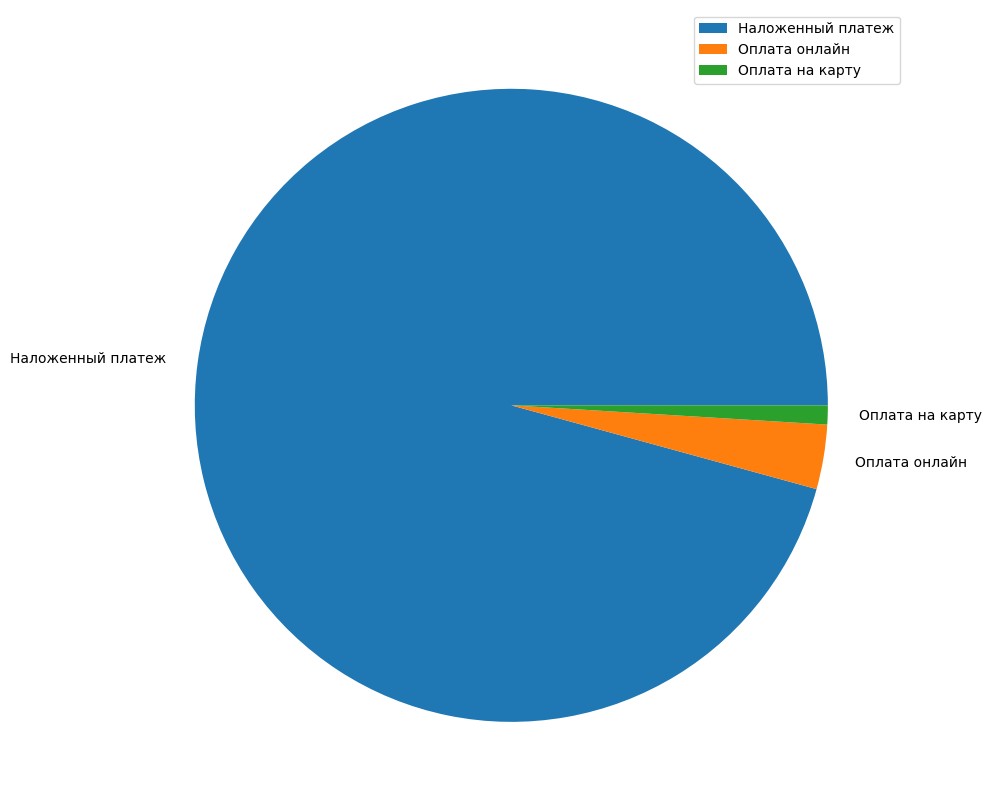

In [48]:
Pie = CLEAN_DATA[['lead_Вид оплаты']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.1)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_Вид оплаты')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\2424669529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


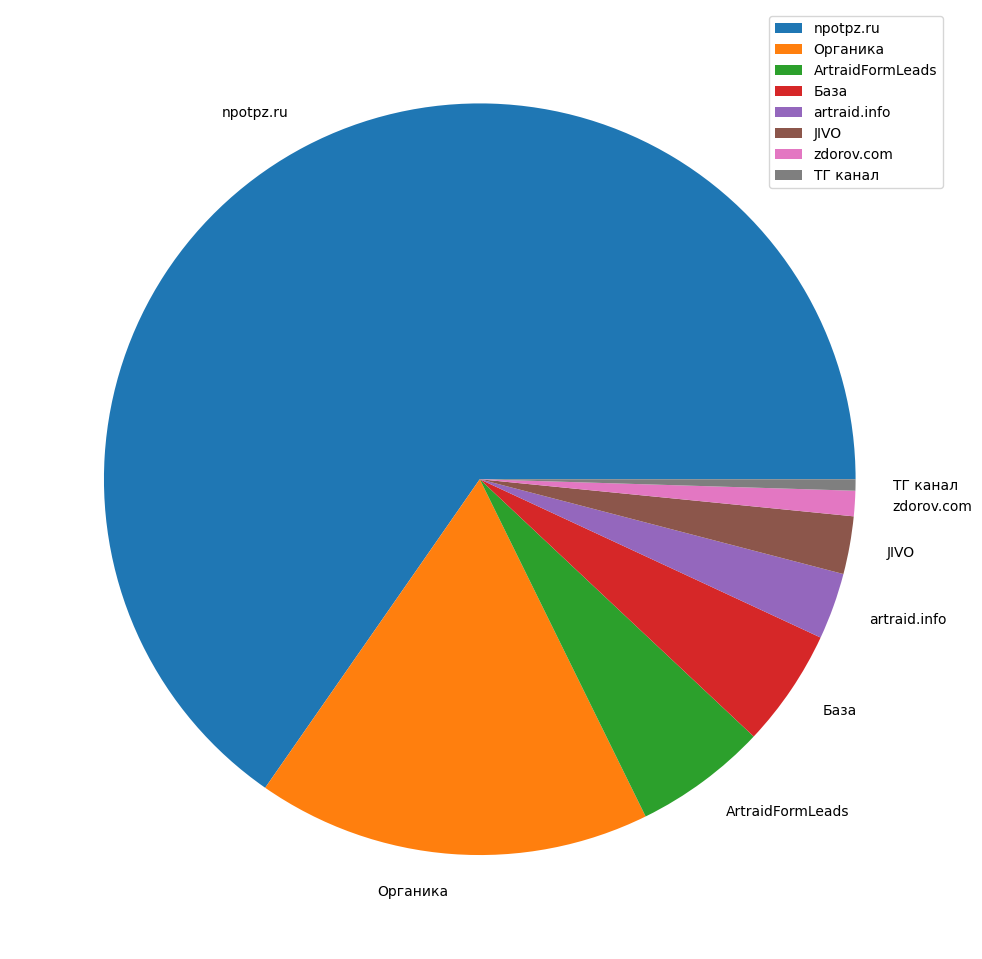

In [36]:
Pie = CLEAN_DATA[['lead_Источник']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_Источник')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\3822613949.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


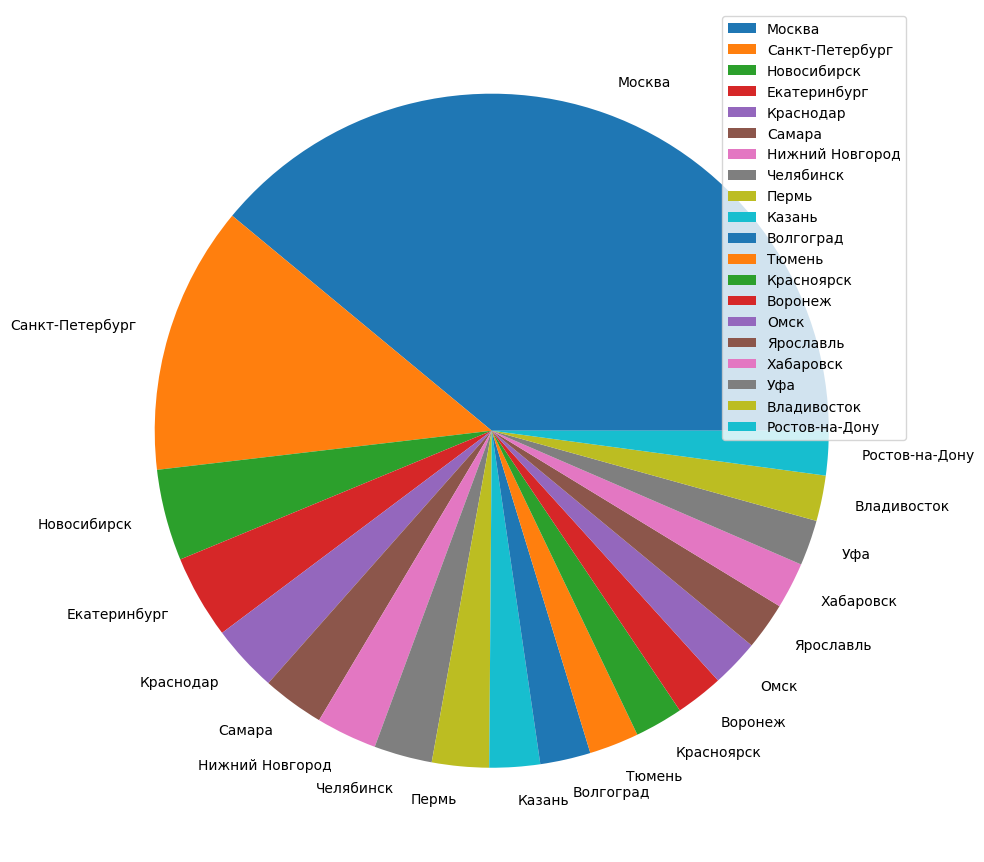

In [37]:
Pie = CLEAN_DATA[['contact_Город']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'contact_Город')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\3106115713.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


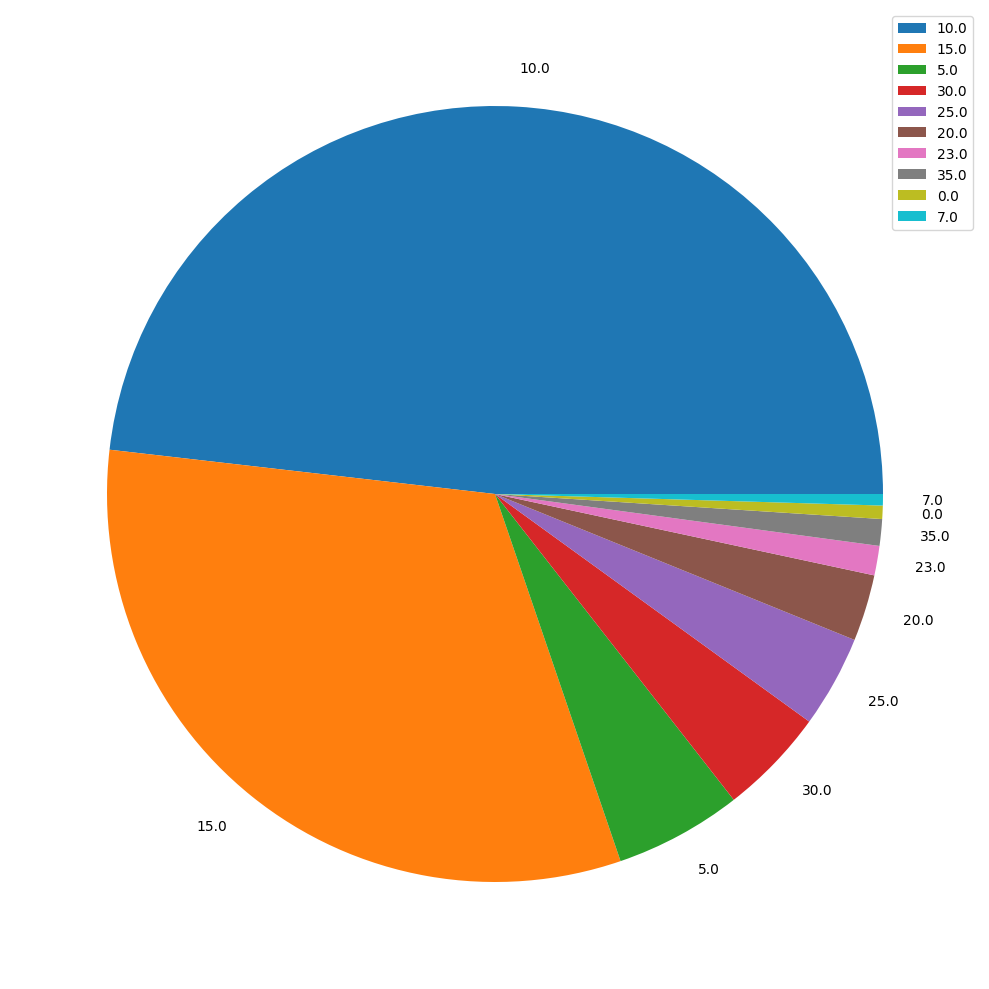

In [40]:
Pie = CLEAN_DATA[['lead_Скидка']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.2)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_Скидка')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\3421719556.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


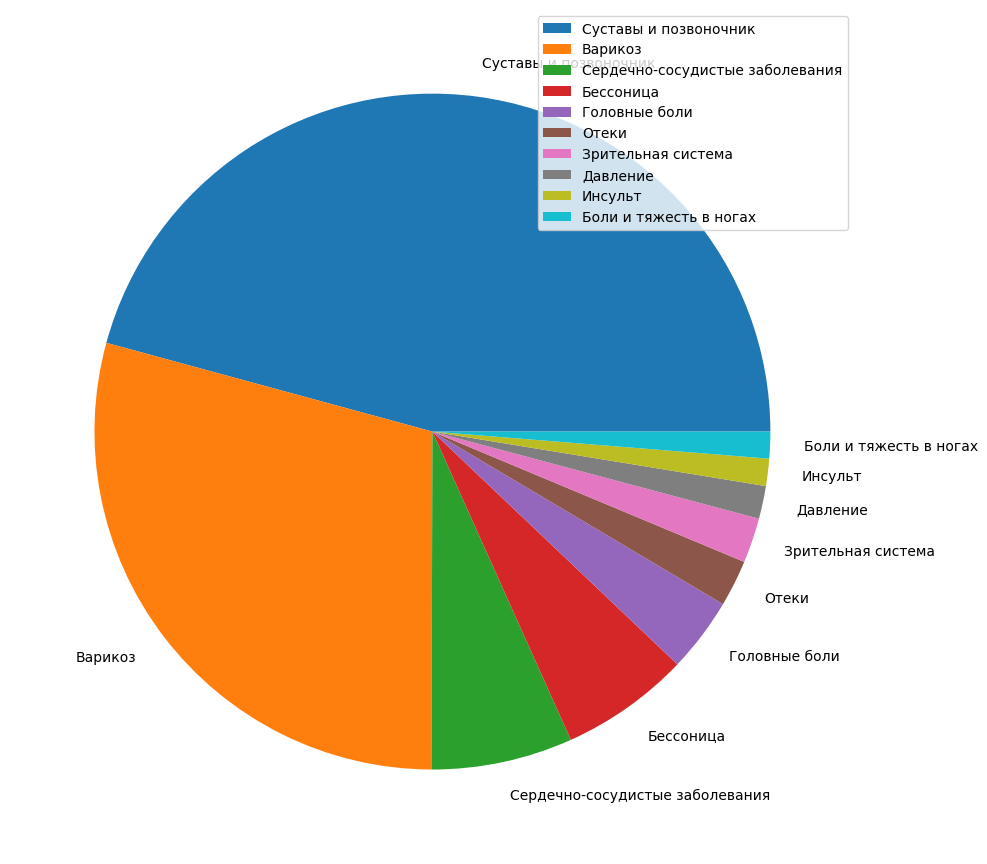

In [41]:
Pie = CLEAN_DATA[['lead_Проблема']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.5)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_Проблема')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\2884521517.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


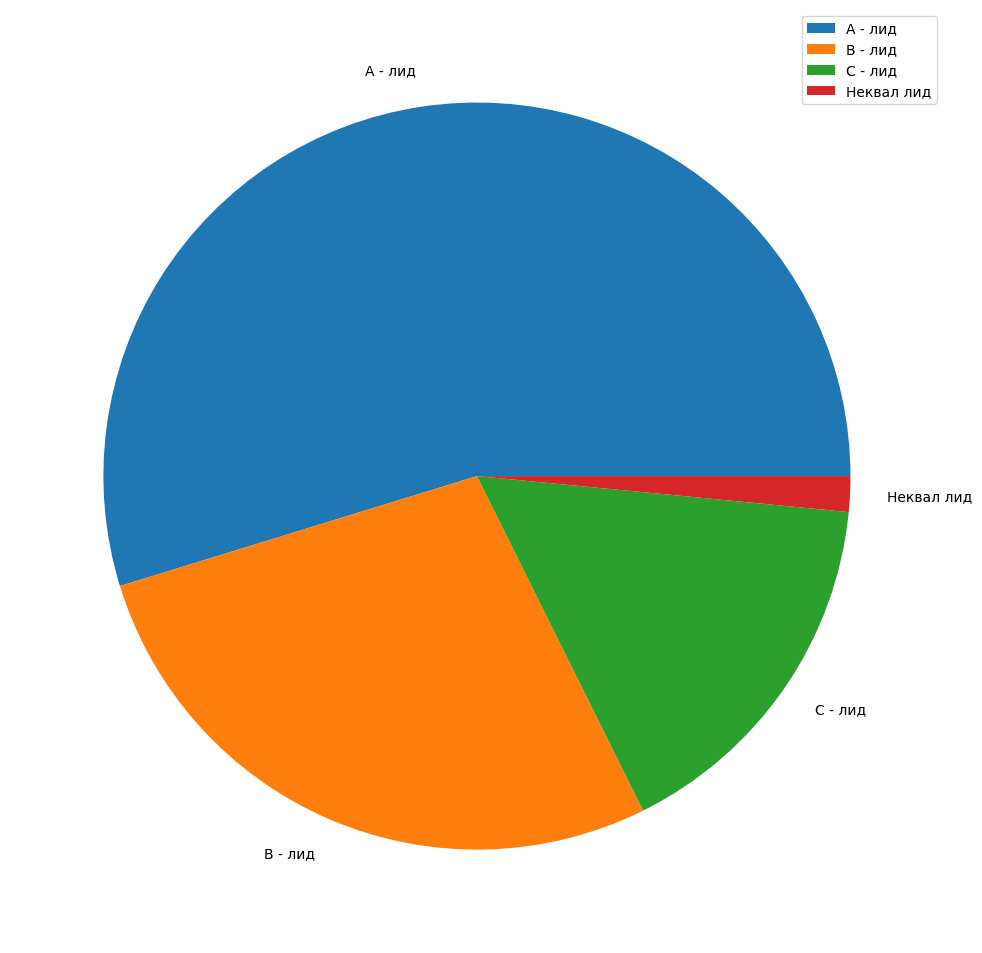

In [42]:
Pie = CLEAN_DATA[['lead_Квалификация лида']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.5)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_Квалификация лида')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\1482441887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


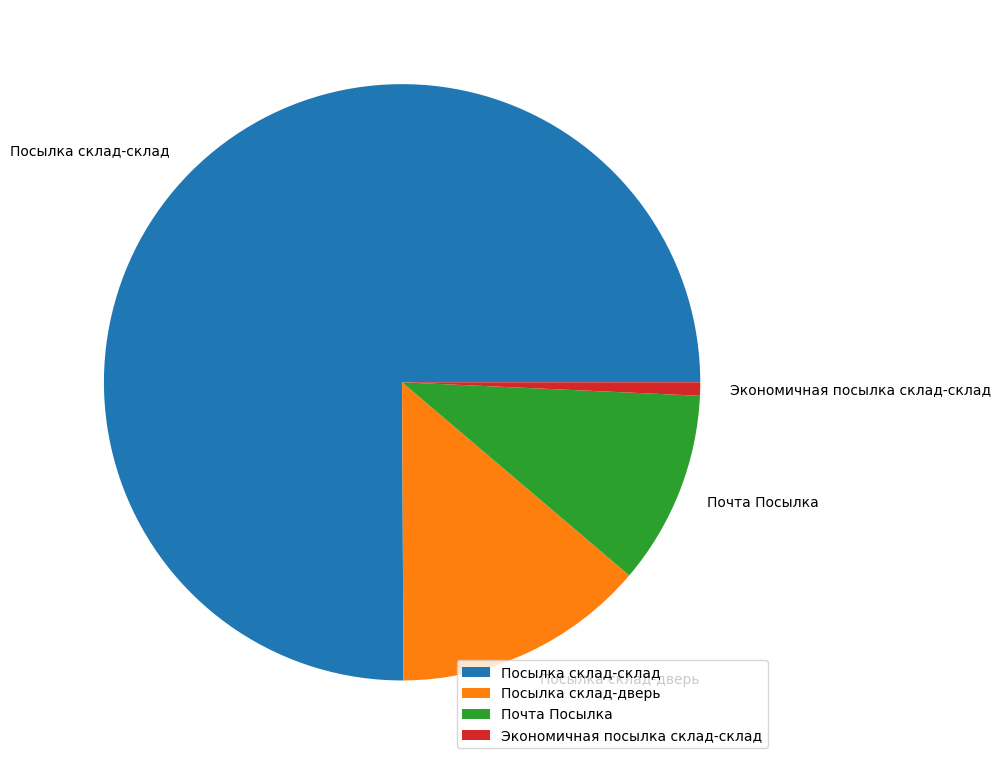

In [43]:
Pie = CLEAN_DATA[['lead_Тариф Доставки']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.5)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_Тариф Доставки')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\978461620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


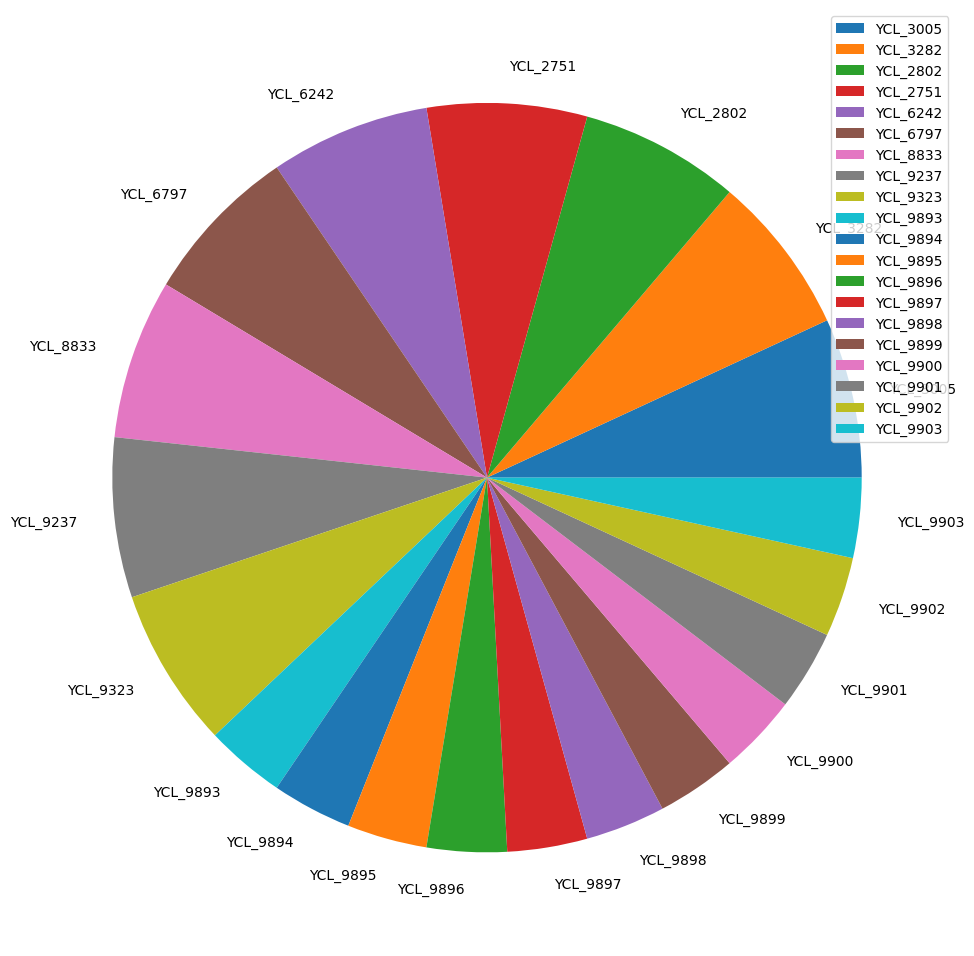

In [44]:
Pie = CLEAN_DATA[['lead_yclid']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.5)
#ax = Pie.plot.pie(y = 'Количество', figsize = (10, 10), ylabel = '')
#ax.legend(loc = 1)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_yclid')

C:\Users\andra\AppData\Local\Temp\ipykernel_9272\2450153028.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Pie['Количество'] = 1


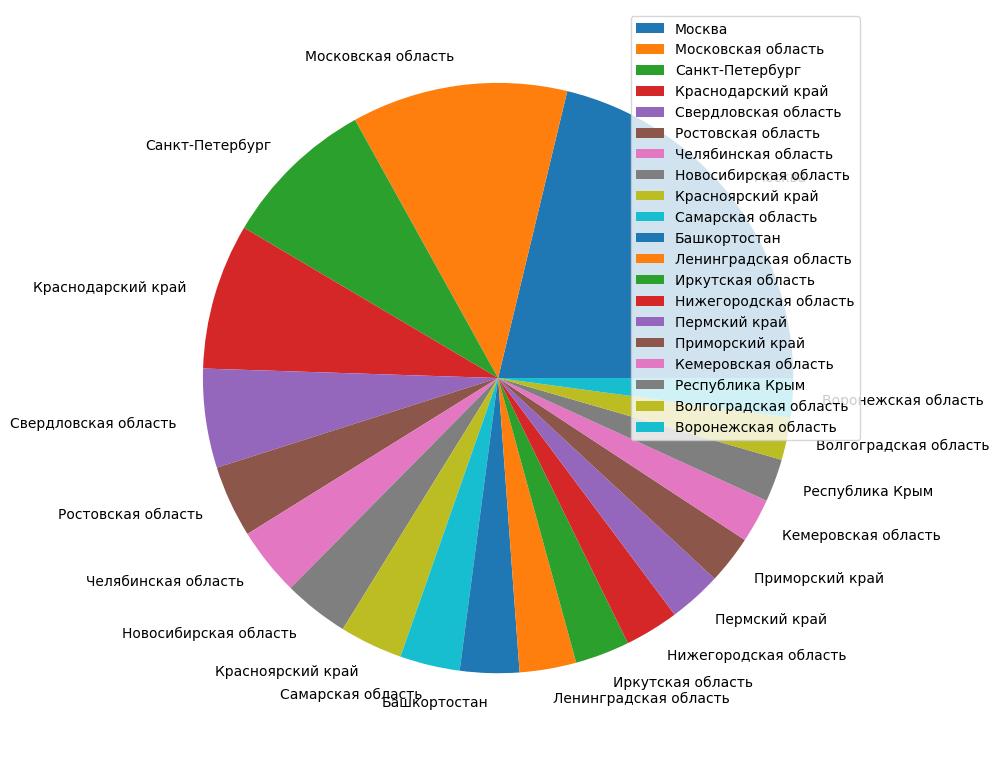

In [49]:
Pie = CLEAN_DATA[['lead_region']]
Pie['Количество'] = 1
Pie = dropRareCategories(Pie, 20, 0.5)
PieChart(Pie, save = True, image_path = image_path, title = 'lead_region')

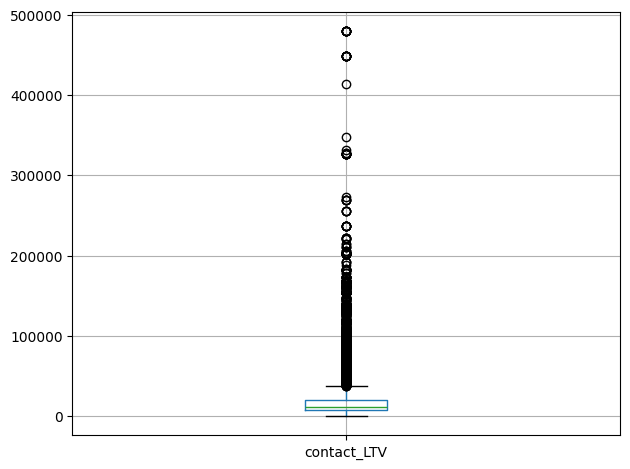

In [51]:
Box = CLEAN_DATA[['contact_LTV']].dropna()
BoxPlot(Box, save = True, image_path = image_path, title = '')

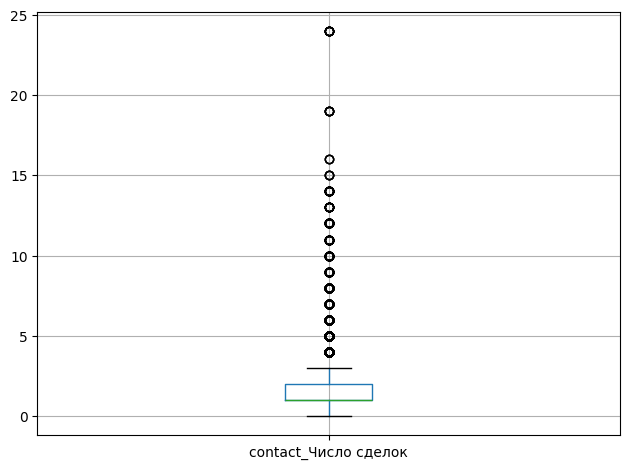

In [52]:
Box = CLEAN_DATA[['contact_Число сделок']].dropna()
BoxPlot(Box, save = True, image_path = image_path, title = '')

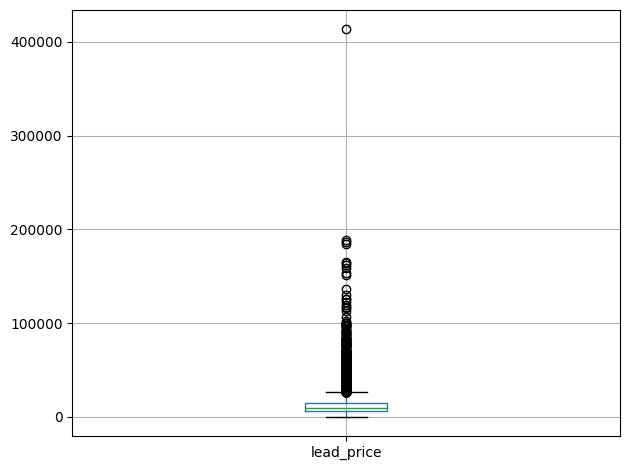

In [53]:
Box = CLEAN_DATA[['lead_price']].dropna()
BoxPlot(Box, save = True, image_path = image_path, title = '')

In [57]:
#70?
#Box = CLEAN_DATA[['days_sale_to_handed']].dropna()
#BoxPlot(Box, save = True, image_path = image_path, title = '')

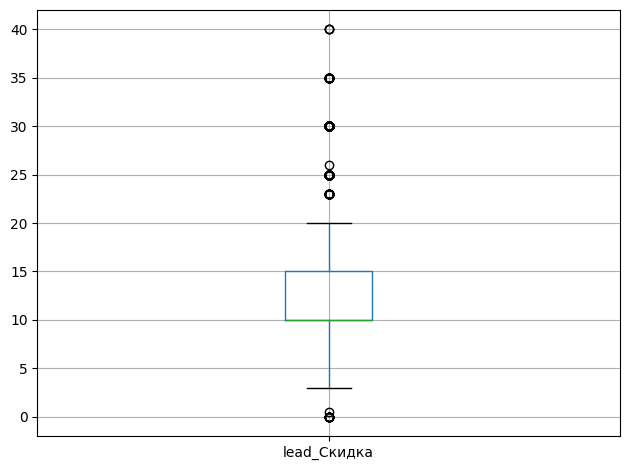

In [58]:
Box = CLEAN_DATA[['lead_Скидка']].dropna()
BoxPlot(Box, save = True, image_path = image_path, title = '')

In [98]:
def sig3OutlDetector(DATA, columns):
    Stds = DATA[columns].std()
    Means = DATA[columns].mean()
    CrvdDATA = DATA[columns]
    CrvdDATA = CrvdDATA[((-3*Stds+Means<=CrvdDATA)&(3*Stds+Means>=CrvdDATA))[columns[0]]]
    return DATA.iloc[CrvdDATA.index.tolist()].reset_index()

In [101]:
sig3OutlDetector(TRIMMED_DATA, ['lead_price'])

,index,sale_ts,sale_date,buyout_flag,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,days_to_outcome,...,has_бандаж_шейный,has_повязка,has_напульсник,has_обувь,has_подушка,has_матрас,has_пояс,has_аксессуары,has_крем,n_product_categories
0,0,2025-03-01 05:35:06,2025-03-01,1,2025-03-07 09:11:37,2025-03-12 12:19:04,2025-03-12 12:20:05,NaT,NaT,11.28,...,False,False,False,False,False,False,False,False,False,1
1,1,2025-03-01 05:51:04,2025-03-01,1,2025-03-07 09:09:52,2025-03-10 12:13:09,2025-03-10 15:23:08,NaT,NaT,9.40,...,False,False,False,False,False,False,False,False,False,1
2,2,2025-03-01 05:54:05,2025-03-01,1,2025-03-06 09:32:46,2025-03-19 03:23:15,2025-03-19 06:32:04,NaT,NaT,18.03,...,False,True,False,False,False,False,False,False,False,1
3,3,2025-03-01 06:18:06,2025-03-01,1,2025-03-05 10:11:51,2025-03-09 10:21:31,2025-03-10 15:23:20,NaT,NaT,9.38,...,False,True,False,False,False,False,False,False,False,1
4,4,2025-03-01 06:42:07,2025-03-01,1,2025-03-06 09:31:10,2025-03-09 06:57:12,2025-03-09 10:22:15,NaT,NaT,8.15,...,False,False,False,True,False,False,False,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17705,17961,2026-03-27 15:06:15,2026-03-27,0,NaT,NaT,NaT,NaT,NaT,0.63,...,False,True,False,False,False,False,False,False,False,1
17706,17962,2026-03-28 07:21:07,2026-03-28,0,NaT,NaT,NaT,NaT,NaT,0.10,...,False,False,False,True,False,False,False,False,False,1
17707,17963,2026-03-28 07:32:08,2026-03-28,0,NaT,NaT,NaT,NaT,NaT,1.07,...,False,True,False,True,False,False,False,True,False,3
17708,17964,2026-03-28 10:35:07,2026-03-28,0,NaT,NaT,NaT,NaT,NaT,0.89,...,False,True,False,True,False,False,False,False,False,2
